# PCMCI Causal Discovery Demo

| Overview row | Method | Teaching point |
|---|---|---|
| Granger/time-series | PCMCI | Lagged conditional independence separates direct temporal causes from indirect lagged correlations. |

Physical story: traffic has a regular daily shape plus incident pulses. Those pulses propagate with a fixed delay: traffic -> queue -> latency -> tickets.

In [ ]:
!pip3 install -q git+https://github.com/NetManAIOps/sktime.git causal-learn tigramite matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

from sktime.causal_discovery import PCMCI, PC

In [2]:
VARIABLES = ["Traffic", "Queue", "Latency", "Tickets"]

rng = np.random.default_rng(4)
n = 220
t = np.arange(n)
pulses = sum(np.exp(-0.5 * ((t - center) / 4) ** 2) for center in [35, 90, 145, 190])
traffic = (
    1.20 * np.sin(2 * np.pi * t / 55)
    + 0.45 * np.sin(2 * np.pi * t / 18)
    + 1.20 * pulses
    + rng.normal(scale=0.08, size=n)
)
queue = np.zeros(n)
latency = np.zeros(n)
tickets = np.zeros(n)

for i in range(2, n):
    queue[i] = 0.55 * queue[i - 1] + 0.65 * traffic[i - 2] + rng.normal(scale=0.08)
    latency[i] = 0.50 * latency[i - 1] + 0.75 * queue[i - 2] + rng.normal(scale=0.08)
    tickets[i] = 0.45 * tickets[i - 1] + 0.80 * latency[i - 2] + rng.normal(scale=0.08)

X_ts = pd.DataFrame(
    {"Traffic": traffic, "Queue": queue, "Latency": latency, "Tickets": tickets}
).iloc[10:].reset_index(drop=True)
X_ts = (X_ts - X_ts.mean()) / X_ts.std()

TRUE_LAGGED_EDGES = {
    ("Traffic[t-2]", "Queue[t]"),
    ("Queue[t-2]", "Latency[t]"),
    ("Latency[t-2]", "Tickets[t]"),
}
LAGGED_NODES = [
    "Traffic[t-2]", "Queue[t-2]", "Latency[t-2]", "Tickets[t-2]",
    "Traffic[t]", "Queue[t]", "Latency[t]", "Tickets[t]",
]
LAGGED_POSITIONS = {
    "Traffic[t-2]": (0, 3), "Queue[t-2]": (0, 2), "Latency[t-2]": (0, 1), "Tickets[t-2]": (0, 0),
    "Traffic[t]": (1.55, 3), "Queue[t]": (1.55, 2), "Latency[t]": (1.55, 1), "Tickets[t]": (1.55, 0),
}

SUMMARY_EDGES = {("Traffic", "Queue"), ("Queue", "Latency"), ("Latency", "Tickets")}
SUMMARY_NODES = VARIABLES
SUMMARY_POSITIONS = {"Traffic": (0, 1), "Queue": (1.2, 1), "Latency": (1.2, 0), "Tickets": (0, 0)}

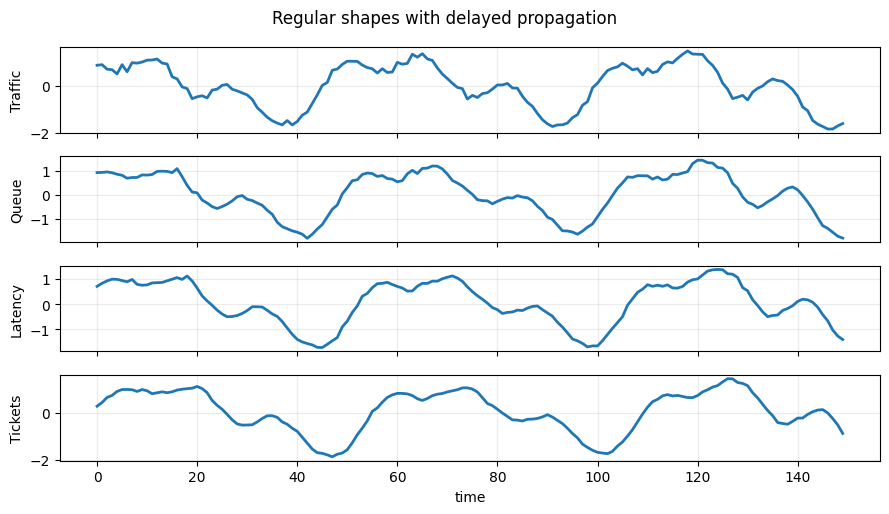

In [3]:
fig, axes = plt.subplots(len(VARIABLES), 1, figsize=(9, 5.2), sharex=True)
for ax, name in zip(axes, VARIABLES):
    ax.plot(X_ts[name].iloc[:150], linewidth=2)
    ax.set_ylabel(name)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("time")
fig.suptitle("Regular shapes with delayed propagation")
plt.tight_layout()

In [4]:
X_lagged = pd.concat(
    [X_ts.add_suffix("[t-1]").shift(1), X_ts.add_suffix("[t-2]").shift(2), X_ts.add_suffix("[t]")],
    axis=1,
).dropna()

pd.DataFrame(
    {
        "correlation with Tickets[t]": {
            "Traffic[t-2]": X_lagged["Traffic[t-2]"].corr(X_lagged["Tickets[t]"]),
            "Queue[t-2]": X_lagged["Queue[t-2]"].corr(X_lagged["Tickets[t]"]),
            "Latency[t-2]": X_lagged["Latency[t-2]"].corr(X_lagged["Tickets[t]"]),
        }
    }
).round(2)

,correlation with Tickets[t]
Traffic[t-2],0.51
Queue[t-2],0.84
Latency[t-2],0.99


In [5]:
COLORS = {
    "correct": "#2ca02c",
    "false positive": "#d62728",
    "missed": "#8c8c8c",
    "ambiguous": "#ff7f0e",
}


def status_for_edge(source, target, kind, true_edges):
    if kind == "directed" and (source, target) in true_edges:
        return "correct"
    if kind == "undirected" and ((source, target) in true_edges or (target, source) in true_edges):
        return "ambiguous"
    if (target, source) in true_edges:
        return "ambiguous"
    return "false positive"


def covered_true_edges(pred_edges, true_edges):
    covered = set()
    for source, target, kind in pred_edges:
        if (source, target) in true_edges:
            covered.add((source, target))
        if kind == "undirected" and (target, source) in true_edges:
            covered.add((target, source))
    return covered


def edge_table(pred_edges, true_edges):
    rows = []
    for source, target, kind in pred_edges:
        rows.append(
            {
                "source": source,
                "target": target,
                "type": kind,
                "status": status_for_edge(source, target, kind, true_edges),
            }
        )
    for source, target in sorted(true_edges - covered_true_edges(pred_edges, true_edges)):
        rows.append(
            {"source": source, "target": target, "type": "true edge", "status": "missed"}
        )
    return pd.DataFrame(rows)


def cpdag_edge_list(adjacency, names):
    edges = []
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if adjacency[i, j] == 1:
                edges.append((source, target, "directed"))
    for i, source in enumerate(names):
        for j, target in enumerate(names):
            if i < j and adjacency[i, j] == -1 and adjacency[j, i] == -1:
                edges.append((source, target, "undirected"))
    return edges


def score_edges(pred_edges, true_edges):
    table = edge_table(pred_edges, true_edges)
    return table["status"].value_counts().reindex(
        ["correct", "ambiguous", "false positive", "missed"], fill_value=0
    )


def draw_edge(ax, source, target, color, positions, node_artists, kind="directed", linestyle="-", rad=0.03):
    arrowstyle = "-|>" if kind == "directed" else "<|-|>"
    patch = FancyArrowPatch(
        positions[source],
        positions[target],
        arrowstyle=arrowstyle,
        mutation_scale=16,
        linewidth=2.5,
        color=color,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}",
        patchA=node_artists[source].get_bbox_patch(),
        patchB=node_artists[target].get_bbox_patch(),
        shrinkA=7,
        shrinkB=7,
        zorder=2,
    )
    ax.add_patch(patch)


def draw_causal_graph(ax, nodes, positions, pred_edges, true_edges, title):
    node_artists = {}
    for node in nodes:
        x, y = positions[node]
        node_artists[node] = ax.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=10.5,
            zorder=3,
            bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "black", "lw": 1.2},
        )
    ax.figure.canvas.draw()

    for source, target in true_edges - covered_true_edges(pred_edges, true_edges):
        draw_edge(ax, source, target, COLORS["missed"], positions, node_artists, linestyle="--", rad=-0.06)

    for source, target, kind in pred_edges:
        status = status_for_edge(source, target, kind, true_edges)
        draw_edge(ax, source, target, COLORS[status], positions, node_artists, kind=kind)

    xs = [p[0] for p in positions.values()]
    ys = [p[1] for p in positions.values()]
    ax.set_xlim(min(xs) - 0.55, max(xs) + 0.55)
    ax.set_ylim(min(ys) - 0.65, max(ys) + 0.65)
    ax.set_title(title)
    ax.axis("off")


def plot_causal_graph(nodes, positions, pred_edges, true_edges, title):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    draw_causal_graph(ax, nodes, positions, pred_edges, true_edges, title)
    add_graph_legend(fig)
    plt.tight_layout()


def plot_graph_comparison(nodes, positions, left_edges, right_edges, true_edges, left_title, right_title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    draw_causal_graph(axes[0], nodes, positions, left_edges, true_edges, left_title)
    draw_causal_graph(axes[1], nodes, positions, right_edges, true_edges, right_title)
    add_graph_legend(fig)
    plt.tight_layout()


def add_graph_legend(fig):
    legend = [
        Line2D([0], [0], color=COLORS["correct"], lw=3, label="correct directed edge"),
        Line2D([0], [0], color=COLORS["ambiguous"], lw=3, label="ambiguous orientation"),
        Line2D([0], [0], color=COLORS["false positive"], lw=3, label="false positive"),
        Line2D([0], [0], color=COLORS["missed"], lw=3, ls="--", label="missed true edge"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=4, frameon=False)


In [7]:
def pcmci_cross_lag_edges(adjacency, names):
    edges = []
    for lag in range(1, adjacency.shape[2]):
        for i, source in enumerate(names):
            for j, target in enumerate(names):
                if source != target and adjacency[i, j, lag] != 0:
                    edges.append((f"{source}[t-{lag}]", f"{target}[t]", "directed"))
    return edges

In [8]:
pcmci = PCMCI(max_lag=3, alpha_level=0.01, pc_alpha=0.01)
pcmci.fit(X_ts)
pcmci_edges = pcmci_cross_lag_edges(pcmci.get_adjacency_matrix(), VARIABLES)

pc = PC(alpha=0.01)
pc.fit(X_ts)
pc_edges = cpdag_edge_list(pc.get_adjacency_matrix(), SUMMARY_NODES)

pd.DataFrame(
    {
        "PCMCI lagged graph": score_edges(pcmci_edges, TRUE_LAGGED_EDGES),
        "PC same-time baseline": score_edges(pc_edges, SUMMARY_EDGES),
    }
)

/Users/moonshot/Project/sktime/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,PCMCI lagged graph,PC same-time baseline
status,,
correct,3,0
ambiguous,0,3
false positive,0,3
missed,0,0


In [9]:
edge_table(pcmci_edges, TRUE_LAGGED_EDGES)

,source,target,type,status
0,Traffic[t-2],Queue[t],directed,correct
1,Queue[t-2],Latency[t],directed,correct
2,Latency[t-2],Tickets[t],directed,correct


In [10]:
edge_table(pc_edges, SUMMARY_EDGES)

,source,target,type,status
0,Traffic,Queue,undirected,ambiguous
1,Traffic,Latency,undirected,false positive
2,Traffic,Tickets,undirected,false positive
3,Queue,Latency,undirected,ambiguous
4,Queue,Tickets,undirected,false positive
5,Latency,Tickets,undirected,ambiguous


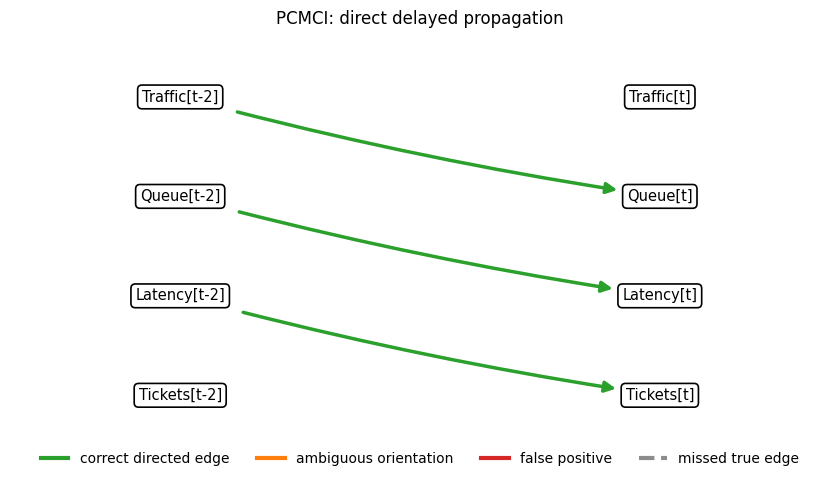

In [11]:
plot_causal_graph(
    LAGGED_NODES,
    LAGGED_POSITIONS,
    pcmci_edges,
    TRUE_LAGGED_EDGES,
    "PCMCI: direct delayed propagation",
)

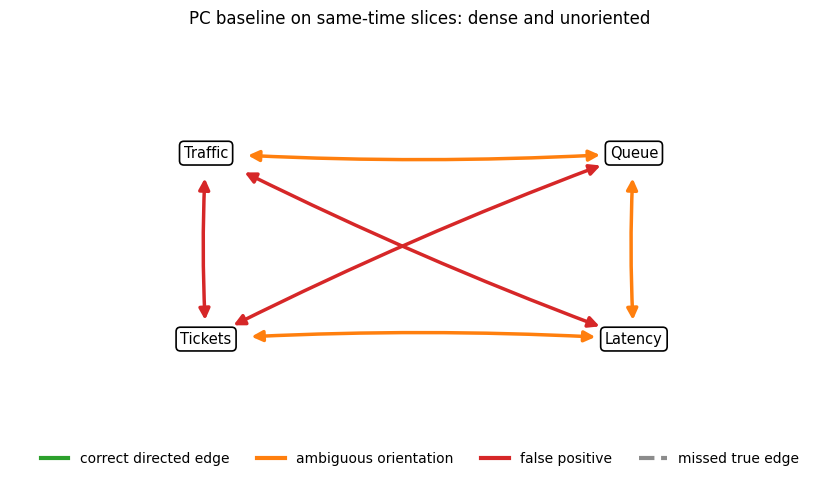

In [12]:
plot_causal_graph(
    SUMMARY_NODES,
    SUMMARY_POSITIONS,
    pc_edges,
    SUMMARY_EDGES,
    "PC baseline on same-time slices: dense and unoriented",
)

Takeaway: the regular shape makes the physical lag visible. PC on same-time slices collapses the temporal information into a dense undirected association graph, while PCMCI uses lagged tests to recover the direct delayed links.